# 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_predict, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, QuantileTransformer, RobustScaler
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from pygam import LinearGAM, s
from scipy.stats import randint, uniform
from sklearn.model_selection import TimeSeriesSplit
from sklearn.decomposition import PCA
from joblib import dump, load
import scipy.sparse
import pickle
import warnings
warnings.filterwarnings("ignore")

# 2. Load and Preprocess Data

In [2]:
df = pd.read_csv("data/movie_data_encoded.csv")

def handle_outliers(df, columns, method='cap'):
    df_clean = df.copy()
    for col in columns:
        Q1 = df_clean[col].quantile(0.05)
        Q3 = df_clean[col].quantile(0.95)
        IQR = Q3 - Q1
        lower_bound = Q1 - 2 * IQR
        upper_bound = Q3 + 2 * IQR
        if method == 'cap':
            df_clean[col] = df_clean[col].clip(lower_bound, upper_bound)
    return df_clean

def check_vif(test):
    vif = pd.DataFrame()
    backup_test = test.copy()
    if 'revenue' in backup_test.columns:
        backup_test.drop('revenue', axis=1, inplace=True)
    vif["feature"] = backup_test.columns
    vif["VIF"] = [variance_inflation_factor(backup_test.values, i)
              for i in range(len(backup_test.columns))]
    print(vif)
    return vif

def plot_residual_diagnostics(y_true, y_pred):
    residuals = y_true - y_pred
    standardized_residuals = (residuals - np.mean(residuals)) / np.std(residuals)
    fig, axs = plt.subplots(2, 2, figsize=(12, 10))
    axs[0, 0].scatter(y_pred, residuals, alpha=0.6)
    axs[0, 0].axhline(0, color='red', linestyle='--')
    axs[0, 0].set_title('Residuals vs Fitted')
    axs[0, 0].set_xlabel('Fitted Values')
    axs[0, 0].set_ylabel('Residuals')
    stats.probplot(residuals, dist="norm", plot=axs[0, 1])
    axs[0, 1].set_title('Normal Q-Q Plot')
    sns.histplot(residuals, bins=30, kde=True, ax=axs[1, 0])
    axs[1, 0].set_title('Histogram of Residuals')
    axs[1, 1].plot(residuals, marker='o', linestyle='', alpha=0.6)
    axs[1, 1].axhline(0, color='red', linestyle='--')
    axs[1, 1].set_title('Residuals vs Observation Order')
    axs[1, 1].set_xlabel('Observation Order')
    axs[1, 1].set_ylabel('Residual')
    plt.tight_layout()
    plt.show()

def error_analysis(y_true, y_pred, X_data):
    residuals = y_true - y_pred
    error_df = X_data.assign(
        true_revenue=y_true / 1e6,
        pred_revenue=y_pred / 1e6,
        residual=residuals / 1e6,
        pct_error=residuals / y_true
    )

    # Top 5 underestimations (model predicted too low)
    print("Top 5 Underestimations:")
    top_underestimates = error_df.nlargest(5, 'residual')
    display(top_underestimates)

    # Top 5 overestimations (model predicted too high)
    print("\nTop 5 Overestimations:")
    top_overestimates = error_df.nsmallest(5, 'residual')
    display(top_overestimates)

    return error_df, top_underestimates, top_overestimates

def check_revenue_distribution(series):
    plt.figure(figsize=(8,5))
    sns.histplot(series, bins=50, kde=True)
    plt.title("Revenue Distribution")
    plt.show()

# Initial data cleaning
df_clean = df[(df['trailer_views'] >= 0) & (df['trailer_likes'] >= 0)].copy()
df_clean = df_clean.dropna(subset=['release_date', 'budget', 'actor_score'])  # Avoid null values
df_clean['release_date'] = pd.to_datetime(df_clean['release_date'], errors='coerce')
df_clean = handle_outliers(df_clean, df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist())

# Feature engineering
df_clean['release_year'] = df_clean['release_date'].dt.year
df_clean['release_year_centered'] = df_clean['release_year'] - df_clean['release_year'].mean()
df_sorted_asc = df_clean.sort_values(by='release_date')

# Select important features based on domain expertise
important_feature_based_on_domain_expertise = ['budget', 'actor_score', 'star_score', 'trailer_views', 'trailer_likes', 'revenue', 'release_year', 'release_year_centered']
test = df_sorted_asc[important_feature_based_on_domain_expertise].copy()

# Transform features
test['revenue'] = np.log1p(test['revenue'])
test['trailer_likes_log'] = np.log1p(test['trailer_likes'])
test['trailer_views_log'] = np.log1p(test['trailer_views'])
test['budget_log'] = np.log1p(test['budget'])
test['actor_score_log'] = np.log1p(test['actor_score'])
test['budget_actor_interaction'] = test['budget_log'] * test['actor_score_log']

test = test[['trailer_views_log', 'trailer_likes_log', 'budget_log', 'budget_actor_interaction',
              'release_year_centered', 'revenue']]

test_nonlinear = test.copy() # Create a copy of the DataFrame for non-linear modeling -> Isn't affected by muticollinearity

# Check revenue distribution
print("Revenue statistics (in millions):")
print(df_clean['revenue'].describe() / 1e6)

Revenue statistics (in millions):
count      0.010490
mean      26.973337
std       39.941745
min        0.000001
25%        2.330202
50%       13.466500
75%       35.101420
max      294.990769
Name: revenue, dtype: float64


In [3]:
# Attempt to solve muticollinearity issue and capture both trailer views and likes influence on revenue.
pca = PCA()
trailer_matrix = test[['trailer_views_log', 'trailer_likes_log']].values
pca.fit(trailer_matrix)

print("Explained variance ratio:", pca.explained_variance_ratio_)

final_pca = PCA(n_components=1)

pca_features = final_pca.fit_transform(trailer_matrix)
test['trailer_pca'] = pca_features

test.drop(columns=['trailer_views_log', 'trailer_likes_log'], inplace=True)

vif = check_vif(test)

Explained variance ratio: [0.97094043 0.02905957]
                    feature       VIF
0                budget_log  1.915352
1  budget_actor_interaction  1.951231
2     release_year_centered  1.035309
3               trailer_pca  1.094471


# 3. Exploratory Data Analysis

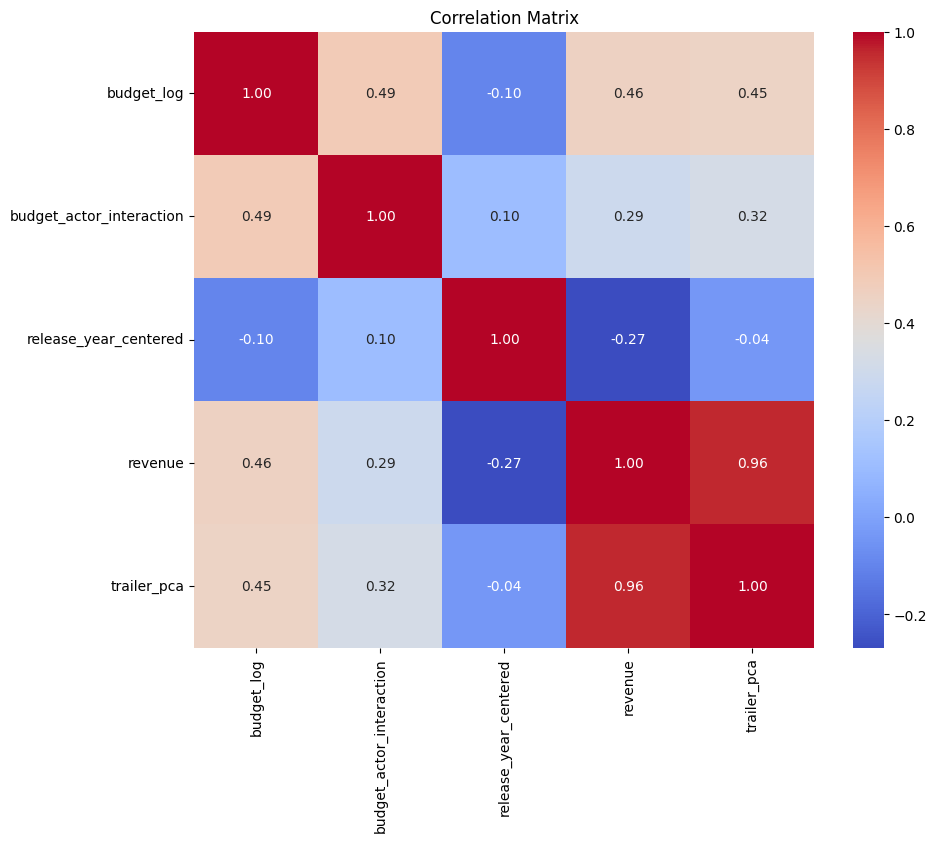

Baseline Model - RMSE: 28.24 Millions, R²: -0.3799


In [4]:
# Calculate correlation matrix
corr_matrix = test.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

# Prepare data for modeling
X = test.drop('revenue', axis=1)
y = df_sorted_asc['revenue']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
y_train_log = np.log1p(y_train)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create polynomial features for more complex models
poly = PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
feature_names = poly.get_feature_names_out(X.columns)

# Scale polynomial features
scaler_poly = StandardScaler()
X_train_poly_scaled = scaler_poly.fit_transform(X_train_poly)
X_test_poly_scaled = scaler_poly.transform(X_test_poly)

# Baseline model (mean prediction)
dummy_pred = np.full_like(y_test, y_train.mean())
RMSE_dummy = np.sqrt(mean_squared_error(y_test, dummy_pred)) / 1e6
R2_dummy = r2_score(y_test, dummy_pred)
print(f"Baseline Model - RMSE: {RMSE_dummy:.2f} Millions, R²: {R2_dummy:.4f}")


# 4. Linear Models

## 4.1 Linear Regression


Fold RMSE: 20.64 Millions R-squared: 0.5036
Fold RMSE: 11.44 Millions R-squared: 0.7834
Fold RMSE: 10.53 Millions R-squared: 0.8073
Fold RMSE: 8.66 Millions R-squared: 0.8652
Fold RMSE: 10.52 Millions R-squared: 0.8143
Average RMSE: 12.36 Millions, Average R-squared: 0.7548
RMSE: 10.33 Millions
R-squared: 0.82


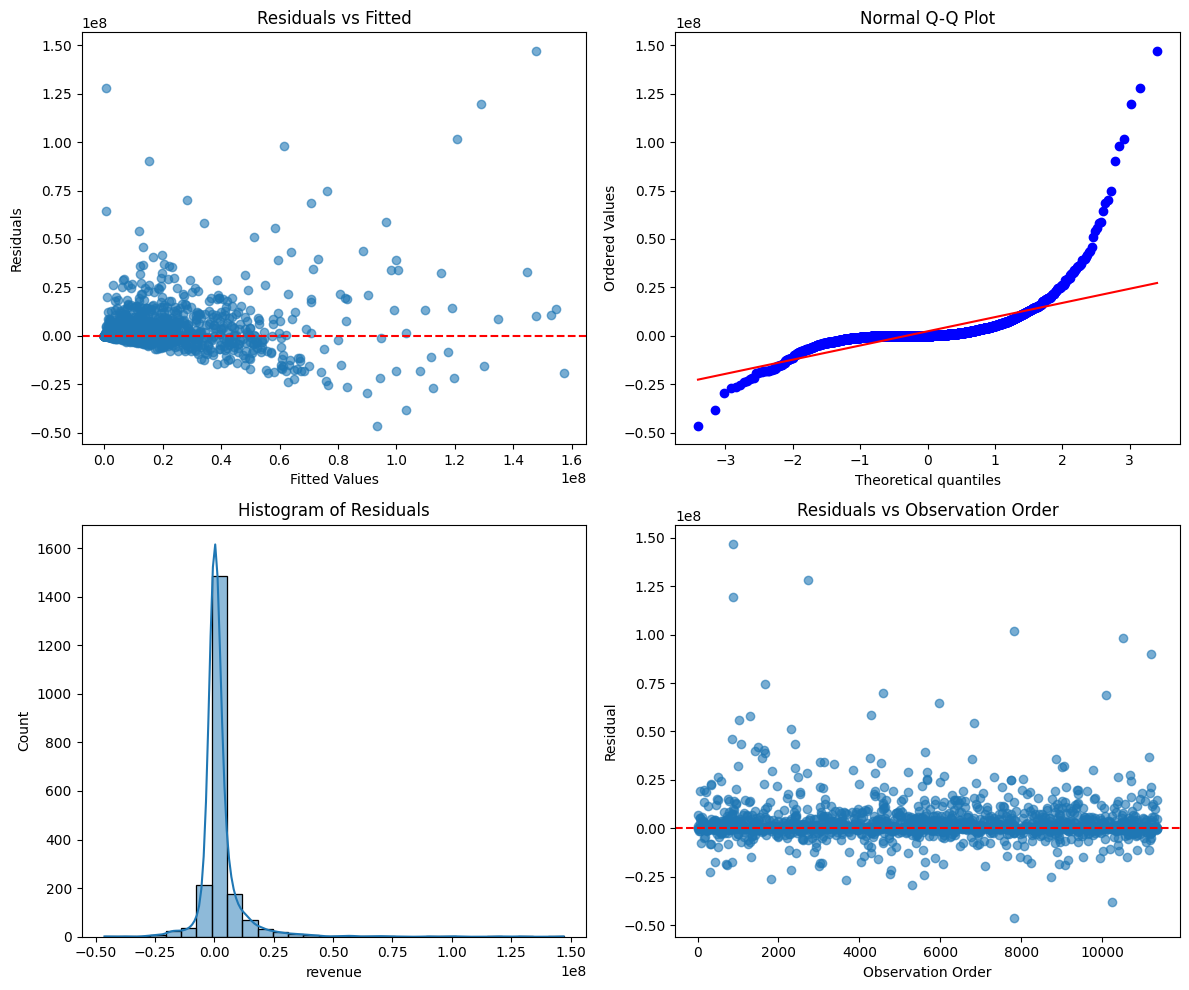

In [5]:
model = LinearRegression()
tscv = TimeSeriesSplit(n_splits=5)

rmse_cv_list = []
r2_cv_list = []
for train_index, test_index in tscv.split(X):
    X_train_cv, X_test_cv = X.iloc[train_index], X.iloc[test_index]
    y_train_cv, y_test_cv = y.iloc[train_index], y.iloc[test_index]

    model = LinearRegression()
    model.fit(X_train_cv, np.log1p(y_train_cv))
    y_pred_cv = np.expm1(model.predict(X_test_cv))

    rmse_cv = np.sqrt(mean_squared_error(y_test_cv, y_pred_cv)) / 1e6
    r2 = r2_score(y_test_cv, y_pred_cv)
    rmse_cv_list.append(rmse_cv)
    r2_cv_list.append(r2)
    print(f"Fold RMSE: {rmse_cv:.2f} Millions", f"R-squared: {r2:.4f}")

print(f"Average RMSE: {np.mean(rmse_cv_list):.2f} Millions, Average R-squared: {np.mean(r2_cv_list):.4f}")  

model.fit(X_train, y_train_log)
y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)
rmse = np.sqrt(mean_squared_error(y_test, y_pred)) / 1e6
r2 = r2_score(y_test, y_pred)
print(f"RMSE: {round(rmse, 2)} Millions")
print(f"R-squared: {round(r2, 2)}")
plot_residual_diagnostics(y_test, y_pred)

In [6]:
residuals, under, over = error_analysis(y_test, y_pred, X_test)

Top 5 Underestimations:


,budget_log,budget_actor_interaction,release_year_centered,trailer_pca,true_revenue,pred_revenue,residual,pct_error
885,19.829997,31.915149,17.946806,5.517345,294.990769,147.930901,147.059868,0.498524
2741,17.103794,0.000000,20.946806,-2.314070,128.624763,0.609390,128.015373,0.995262
883,19.829997,21.785478,20.946806,5.486828,248.701339,129.023400,119.677939,0.481211
7826,19.260222,37.478661,19.946806,5.320662,222.483376,120.813515,101.669861,0.456977
10517,19.020717,34.080549,20.946806,4.387678,159.572953,61.437231,98.135721,0.614990



Top 5 Overestimations:


,budget_log,budget_actor_interaction,release_year_centered,trailer_pca,true_revenue,pred_revenue,residual,pct_error
7825,18.537843,20.365902,16.946806,4.814354,46.913499,93.239942,-46.326442,-0.987486
10237,16.476675,11.420761,14.946806,4.888481,65.156272,103.311128,-38.154856,-0.585590
5304,19.240432,30.966280,17.946806,4.791309,60.334860,89.808923,-29.474063,-0.488508
3663,19.366039,37.684572,21.946806,5.319979,85.633446,112.581481,-26.948034,-0.314691
1817,19.360507,21.269691,15.946806,4.588705,56.948272,83.232725,-26.284452,-0.461550


In [7]:
check = df_clean.loc[over.index[0]]
print(check)

Unnamed: 0                                                      8660
name                               Spider-Man: Into the Spider-Verse
genres                                    Action,Adventure,Animation
directors                Bob Persichetti,Peter Ramsey,Rodney Rothman
writers                                     Phil Lord,Rodney Rothman
                                            ...                     
has_trailer                                                      1.0
has_keywords                                                       1
keyword_embedding                                           0.037095
release_year                                                    2018
release_year_centered                                      16.946806
Name: 7825, Length: 62, dtype: object


In [8]:
check = df_clean.loc[under.index[0]]
print(check)

Unnamed: 0                                                             948
name                                                     Avengers: Endgame
genres                                             Action,Adventure,Sci-Fi
directors                                          Anthony Russo,Joe Russo
writers                  Christopher Markus,Stephen McFeely,Stan Lee,Ja...
                                               ...                        
has_trailer                                                            1.0
has_keywords                                                             1
keyword_embedding                                                 0.438809
release_year                                                          2019
release_year_centered                                            17.946806
Name: 885, Length: 62, dtype: object


In [ ]:
dump(model, 'linear_model.joblib')

## 4.2 Elastic Net 

In [9]:
EL_tune = ElasticNet()

search_space = {
    'alpha': np.logspace(-4, 2, 50),  # Regularization strength (L1 + L2)
    'l1_ratio': np.linspace(0, 1, 21),  # Balance between L1 (lasso) and L2 (ridge)
}

grid_search = GridSearchCV(
    estimator=EL_tune,
    param_grid=search_space,
    cv=KFold(n_splits=5),
    scoring='neg_mean_squared_error',
    n_jobs=-1  # Optional: speeds things up if you have multiple cores
)

grid_search.fit(X_train, y_train_log)

GridSearchCV(cv=KFold(n_splits=5, random_state=None, shuffle=False),
             estimator=ElasticNet(), n_jobs=-1,
             param_grid={'alpha': array([1.00000000e-04, 1.32571137e-04, 1.75751062e-04, 2.32995181e-04,
       3.08884360e-04, 4.09491506e-04, 5.42867544e-04, 7.19685673e-04,
       9.54095476e-04, 1.26485522e-03, 1.67683294e-03, 2.22299648e-03,
       2.94705170e-03, 3.90693994e-03, 5.17947468e-03...
       2.55954792e+00, 3.39322177e+00, 4.49843267e+00, 5.96362332e+00,
       7.90604321e+00, 1.04811313e+01, 1.38949549e+01, 1.84206997e+01,
       2.44205309e+01, 3.23745754e+01, 4.29193426e+01, 5.68986603e+01,
       7.54312006e+01, 1.00000000e+02]),
                         'l1_ratio': array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
       0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ])},
             scoring='neg_mean_squared_error')

In [10]:
model = grid_search.best_estimator_
y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)
rmse = np.sqrt(mean_squared_error(y_test, y_pred)) / 1e6
r2 = r2_score(y_test, y_pred)
print(f"RMSE: {round(rmse, 2)} Millions")
print(f"R-squared: {round(r2, 2)}")

RMSE: 10.55 Millions
R-squared: 0.81


In [ ]:
dump(model, 'elastic_net.joblib')

# 5. Non-linear Model

## 5.1 Generalized Additive Model (GAM)

RMSE: 10.07 Millions
R-squared: 0.82


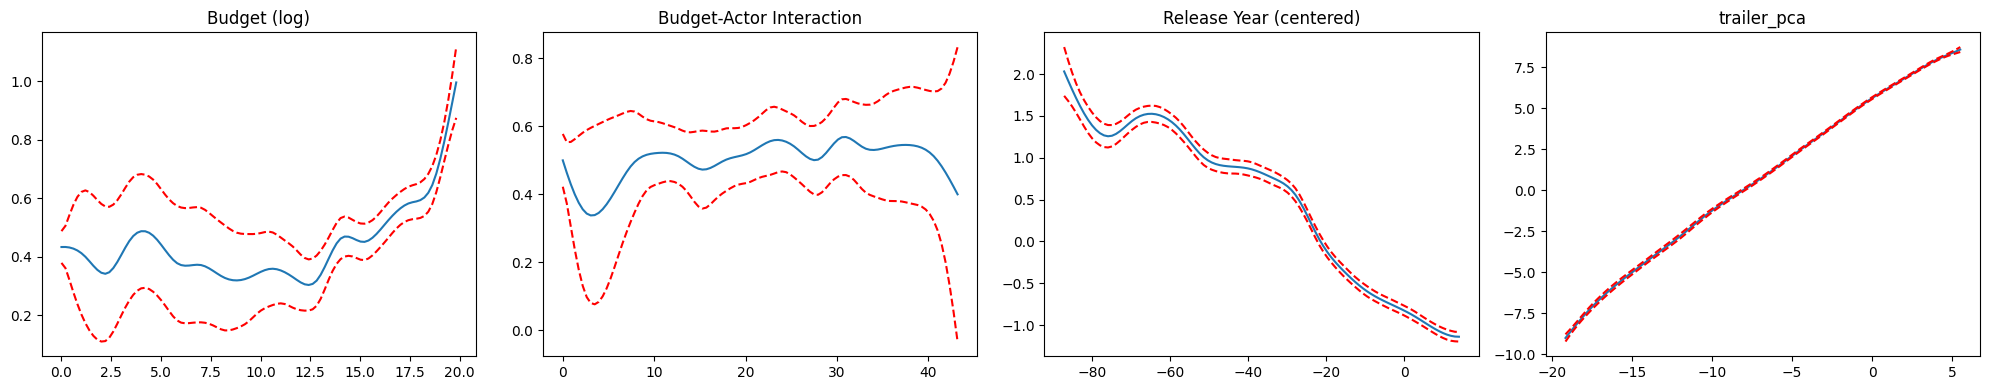

In [11]:
np.int = int
scipy.sparse.csr_matrix.A = property(lambda self: self.toarray())
gam = LinearGAM(s(0) + s(1) + s(2) + s(3)).fit(X_train, y_train_log)
y_pred_log = gam.predict(X_test)
y_pred = np.expm1(y_pred_log)
rmse = np.sqrt(mean_squared_error(y_test, y_pred)) / 1e6
r2 = r2_score(y_test, y_pred)
print(f"RMSE: {round(rmse, 2)} Millions")
print(f"R-squared: {round(r2, 2)}")

scipy.sparse.csc_matrix.A = property(lambda self: self.toarray())
fig, axs = plt.subplots(1, 4, figsize=(20, 4))
titles = ["Budget (log)", "Budget-Actor Interaction", "Release Year (centered)", "trailer_pca"]
for i, ax in enumerate(axs):
    XX = gam.generate_X_grid(term=i)
    ax.plot(XX[:, i], gam.partial_dependence(term=i, X=XX))
    ax.plot(XX[:, i], gam.partial_dependence(term=i, X=XX, width=0.95)[1], c='r', ls='--')
    ax.set_title(titles[i])
plt.tight_layout()
plt.show()

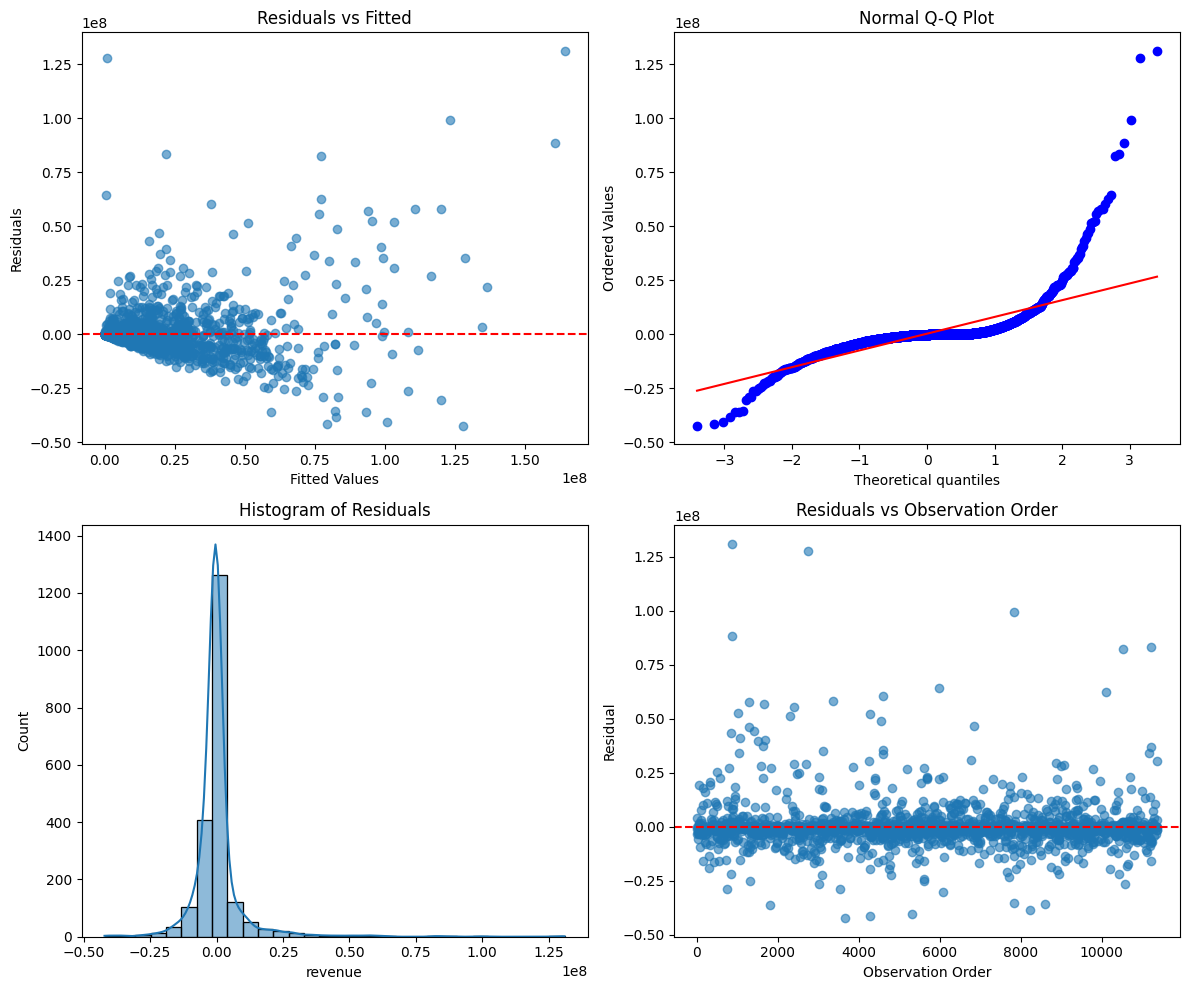

In [12]:
plot_residual_diagnostics(y_test, y_pred)

## 5.2 Random Forest Regressor


Best RF parameters: {'max_depth': 10, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 341}
Random Forest - RMSE: 10.28 Millions, R²: 0.8171


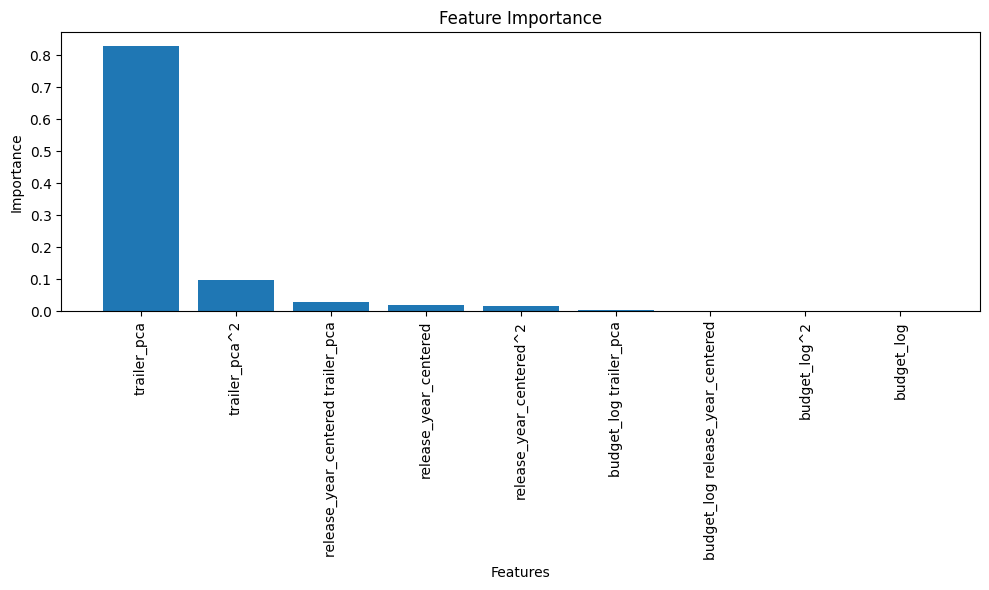

In [13]:
RFR_tune = RandomForestRegressor(random_state=42)
param_dist = {
    'n_estimators': randint(100, 1000),
    'max_depth': [5, 10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.5, None]
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
rand_search = RandomizedSearchCV(RFR_tune, param_distributions=param_dist,
                               n_iter=10, cv=kf, scoring='neg_mean_squared_error',
                               random_state=42, n_jobs=-1)
rand_search.fit(X_train_poly_scaled, y_train_log.values.ravel())
print(f"Best RF parameters: {rand_search.best_params_}")

Best_RFR = rand_search.best_estimator_
y_pred_rf_log = Best_RFR.predict(X_test_poly_scaled)
y_pred_rf = np.expm1(y_pred_rf_log)
RMSE_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf)) / 1e6
R2_rf = r2_score(y_test, y_pred_rf)
print(f"Random Forest - RMSE: {RMSE_rf:.2f} Millions, R²: {R2_rf:.4f}")

# Feature importance
importances = Best_RFR.feature_importances_
feature_importances = pd.DataFrame(importances, index=feature_names,
                                 columns=["importance"]).sort_values("importance", ascending=False)

# Select important features (importance >= 0.001)
important_features = feature_importances[feature_importances["importance"] >= 0.001].index

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.title("Feature Importance")
important_importance_values = feature_importances.loc[important_features, "importance"]
plt.bar(range(len(important_features)), important_importance_values, align="center")
plt.xticks(range(len(important_features)), important_features, rotation=90)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

# Map feature names to column indices for reduced feature set
important_feature_indices = [i for i, name in enumerate(feature_names) if name in important_features]
X_train_poly_important = X_train_poly_scaled[:, important_feature_indices]
X_test_poly_important = X_test_poly_scaled[:, important_feature_indices]


## 5.4  XGBoost with Time-Based Split


Data shape for time-based split - X: (11364, 49), y: (11364,)
Time-based splitting by release_year...
Train years: [1914 1915 1916 1918 1919 1920 1921 1922 1923 1924 1925 1926 1927 1928
 1929 1930 1931 1932 1933 1934 1935 1936 1937 1938 1939 1940 1941 1942
 1943 1944 1945 1946 1947 1948 1949 1950 1951 1952 1953 1954 1955 1956
 1957 1958 1959 1960 1961 1962 1963 1964 1965 1966 1967 1968 1969 1970
 1971 1972 1973 1974 1975 1976 1977 1978 1979 1980 1981 1982 1983 1984
 1985 1986 1987 1988 1989 1990 1991 1992 1993 1994 1995 1996 1997 1998
 1999 2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012
 2013 2014 2015]
Test years: [2015 2016 2017 2018 2019 2020 2021 2022 2023 2024]
X_train_time shape: (9091, 49), X_test_time shape: (2273, 49)

=== PERFORMANCE METRICS (Time-based Split) ===
Test RMSE: 9.82 Millions
Test R²: 0.8427


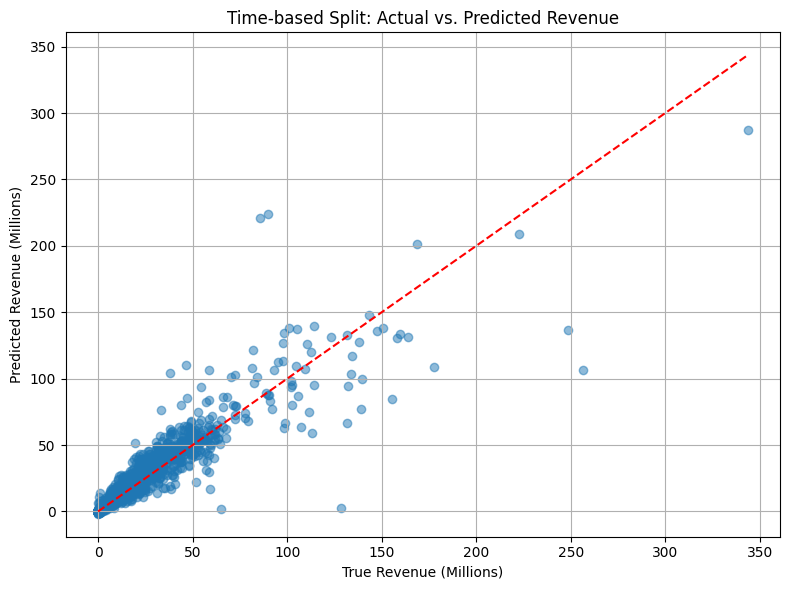

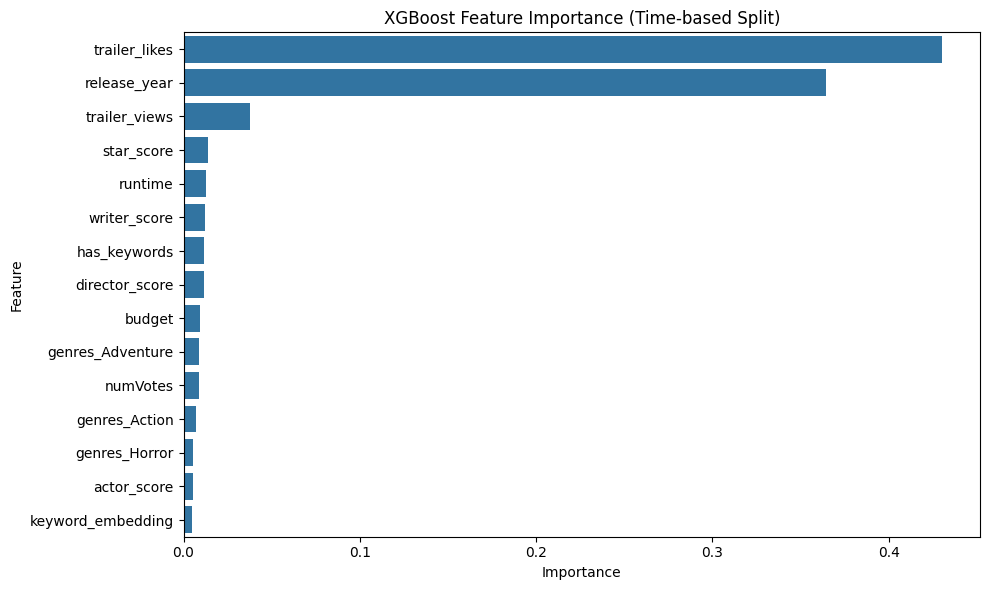

In [16]:
import gc
gc.collect()

# Use the original dataframe for this approach
df_for_time_split = df.copy()

# Ensure we have a release_year column
if "release_date" not in df_for_time_split.columns:
    print("release_date column not found in the original dataset.")
else:
    # Convert to datetime and extract year if not already done
    df_for_time_split["release_date"] = pd.to_datetime(df_for_time_split["release_date"], errors="coerce")
    df_for_time_split["release_year"] = df_for_time_split["release_date"].dt.year
    df_for_time_split = df_for_time_split.sort_values(by='release_date')

    # Define columns to drop for feature selection
    drop_cols = [
        "Unnamed: 0", "name", "genres", "directors", "writers",
        "actors", "original_language", "production_companies",
        "release_date", "keywords", "revenue"  # we keep 'release_year'!
    ]

    # Create feature matrix and target
    y_time = df_for_time_split["revenue"]
    X_time = df_for_time_split.drop(columns=drop_cols, errors="ignore")

    numeric_cols = X_time.select_dtypes(include=[np.number]).columns
    X_time = X_time[numeric_cols]

    print(f"Data shape for time-based split - X: {X_time.shape}, y: {y_time.shape}")

    # Perform time-based split
    #all_years = sorted(X_time["release_year"].dropna().unique())
    #boundary_year = 2015  # Choose a reasonable boundary
    #train_years = [year for year in all_years if year < boundary_year]
    #test_years = [year for year in all_years if year >= boundary_year]

    X_train, X_test, y_train, y_test = train_test_split(X_time, y_time, test_size=0.2, shuffle=False)

    print(f"Time-based splitting by release_year...")
    print("Train years:", X_train["release_year"].unique())
    print("Test years:", X_test["release_year"].unique())

    # Build masks for splitting
    #train_mask = X_time["release_year"].isin(train_years)
    #test_mask = X_time["release_year"].isin(test_years)

    # Split data
    #X_train_time = X_time[train_mask].copy()
    #X_test_time = X_time[test_mask].copy()
    #y_train_time = y_time[train_mask]
    #y_test_time = y_time[test_mask]

    # Verify split
    overlap = set(X_train["release_year"].unique()).intersection(X_test["release_year"].unique())
    if overlap:
        print("WARNING: Overlap in train/test years:", overlap)
    else:
        print("No overlap in train/test years (good).")

    print(f"X_train_time shape: {X_train.shape}, X_test_time shape: {X_test.shape}")

    # Preprocessing - select only numeric columns
    #numeric_cols = X_train_time.select_dtypes(include=[np.number]).columns
    #X_train_time_numeric = X_train_time[numeric_cols].fillna(0)
    #X_test_time_numeric = X_test_time[numeric_cols].fillna(0)

    # Scale the features
    scaler_time = StandardScaler()
    X_train_time_scaled = scaler_time.fit_transform(X_train)
    X_test_time_scaled = scaler_time.transform(X_test)

    # Train the model
    xgb_time = XGBRegressor(
        random_state=42,
        objective="reg:squarederror",
        n_estimators=300,
        max_depth=5,
        learning_rate=0.1
    )

    xgb_time.fit(X_train_time_scaled, y_train)

    # Make predictions
    y_pred_time = xgb_time.predict(X_test_time_scaled)

    # Evaluate
    rmse_time = np.sqrt(mean_squared_error(y_test, y_pred_time)) / 1e6
    r2_time = r2_score(y_test, y_pred_time)

    print("\n=== PERFORMANCE METRICS (Time-based Split) ===")
    print(f"Test RMSE: {rmse_time:.2f} Millions")
    print(f"Test R²: {r2_time:.4f}")

    # Quick scatter plot
    plt.figure(figsize=(8,6))
    plt.scatter(y_test / 1e6, y_pred_time / 1e6, alpha=0.5)
    plt.plot([y_test.min() / 1e6, y_test.max() / 1e6],
             [y_test.min() / 1e6, y_test.max() / 1e6], 'r--')
    plt.xlabel("True Revenue (Millions)")
    plt.ylabel("Predicted Revenue (Millions)")
    plt.title("Time-based Split: Actual vs. Predicted Revenue")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Plot feature importance
    feature_importance = pd.DataFrame({
        'Feature': numeric_cols,
        'Importance': xgb_time.feature_importances_
    }).sort_values('Importance', ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importance.head(15))
    plt.title('XGBoost Feature Importance (Time-based Split)')
    plt.tight_layout()
    plt.show()